# PCA Analysis on HIGGS Dataset

This notebook performs Principal Component Analysis (PCA) on a subsample of the UCI HIGGS dataset to reduce dimensionality from 28 features to 2, 5, and 10 components. 

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

## Load the Subsampled Data

In [2]:
df = pd.read_csv('../data/processed/X_sample.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200000, 28)


,lepton_pT,lepton_eta,lepton_phi,missing_E_mag,missing_E_phi,jet1_pT,jet1_eta,jet1_phi,jet1_btag,jet2_pT,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.138683,-0.726635,-0.005790,0.204118,0.153842,1.585904,-0.045576,-1.448527,1.086538,1.598471,...,-2.439800,0.073642,0.000000,1.790497,1.730592,0.980587,0.743065,2.378752,1.534863,1.227558
1,0.404633,1.014821,-1.050041,1.136441,-1.403536,3.218436,-1.944837,0.801788,0.000000,2.238942,...,-1.174742,-0.912542,0.000000,1.072789,0.649697,0.981147,2.004577,0.521853,1.246037,1.461494
2,1.137585,0.325251,1.453598,0.804114,0.893516,0.418095,-1.164536,-0.585919,0.000000,0.653565,...,0.280201,-0.982461,3.101961,0.816500,0.933867,0.988956,0.852772,0.415455,0.737194,0.691437
3,1.380438,-0.595149,-0.727112,0.465392,-0.057453,0.399224,-0.076273,1.080084,2.173076,0.644878,...,1.261267,1.129085,0.000000,0.563342,0.857068,0.992465,0.875139,0.512037,0.686362,0.887047
4,0.962628,1.191110,-1.161568,1.541759,0.569159,1.337374,0.810973,0.458075,1.086538,0.549946,...,0.413452,1.309431,3.101961,1.596246,1.146864,1.687726,1.178736,0.925320,1.094308,0.991339


## Standardize the Data

PCA is sensitive to the scale of features. Standardizing the data makes each feature have mean=0 and standard deviation=1, so no feature dominates the analysis.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Run PCA with Different Component Numbers

This reduces the 28-dimensional data to 2, 5, and 10 components. Runtime is recorded.

In [4]:
# Store results for comparison
pca_results = {}

for n_components in [2, 5, 10]:
    start_time = time.time()

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    elapsed = time.time() - start_time

    pca_results[n_components] = {
        'transformed_data': X_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
        'runtime': elapsed
    }

    print(f"PCA with {n_components} components:")
    print(f"    Runtime: {elapsed:.2f} seconds")
    print(f"    Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
    print()

PCA with 2 components:
    Runtime: 0.04 seconds
    Total variance explained: 21.58%

PCA with 5 components:
    Runtime: 0.04 seconds
    Total variance explained: 37.84%

PCA with 10 components:
    Runtime: 0.04 seconds
    Total variance explained: 59.73%



### PCA Results Summary

| Components | Variance Explained | Runtime |
|------------|-------------------|---------|
| 2          | 21.58%            | 0.04s   |
| 5          | 37.84%            | 0.04s   |
| 10         | 59.73%            | 0.04s   |

**Observation:** The HIGGS features are relatively uncorrelated, this is why the 10 components only captures approximately 60% of the variance. This suggests the features each contribute unique information to the dataset.

## Variance Explained Visualization

This plot shows how much variance each principal component explains individually (bars) and cumulatively (line). The green dashed line marks the 95% variance threshold.

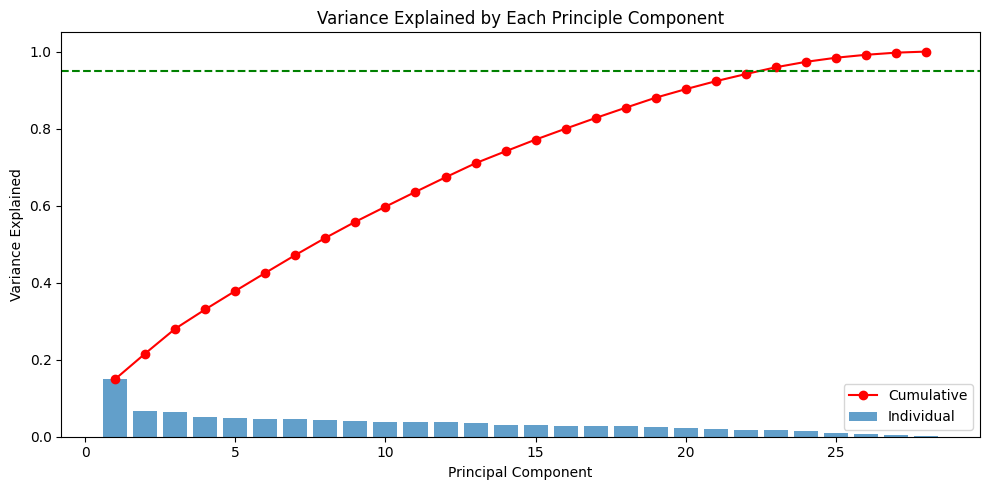

In [5]:
pca_full = PCA(n_components = 28)
pca_full.fit(X_scaled)

plt.figure(figsize = (10,5))
plt.bar(range(1, 29), pca_full.explained_variance_ratio_, alpha = 0.7, label = "Individual")
plt.plot(range(1,29), np.cumsum(pca_full.explained_variance_ratio_), "r-o", label = "Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Variance Explained by Each Principle Component")
plt.legend()
plt.axhline(y = 0.95, color = "g", linestyle = "--", label = "95% threshold")
plt.tight_layout()
plt.savefig("../results/visualizations/variance_explained.png")
plt.show()

### Variance Plot Interpretation

The plot shows a gradual decline in variance explained per component rather than a steep drop-off. This confirms that the 28 HIGGS features are relatively independent, with no small subset of components capturing the majority of variance.

To reach 95% variance, around 22 components are needed.

## 2D PCA Scatter Plot

Visualizing the data projected onto the first two principal components helps identify any clustering structure.

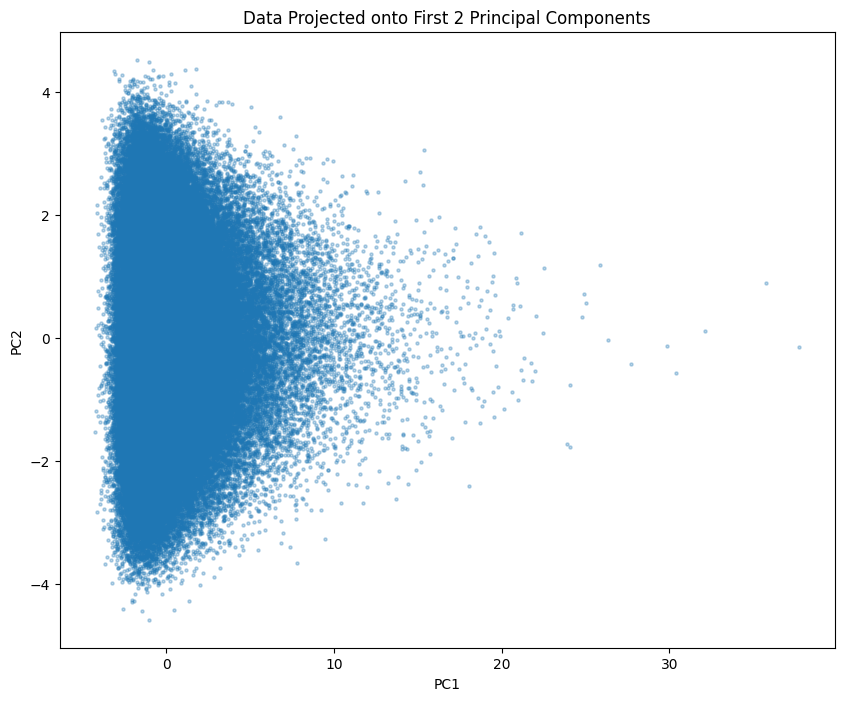

In [6]:
X_2d = pca_results[2]["transformed_data"]

plt.figure(figsize = (10,8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha = 0.3, s = 5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data Projected onto First 2 Principal Components")
plt.savefig("../results/visualizations/pca_2d_scatter.png")
plt.show()

### 2D Scatter Plot Interpretation

The 2D projection shows a lot of data points centered around PC1 ≈ 0 with a long tail extending toward higher PC1 values. The data spreads fairly symmetrically along PC2 (from -4 to 4).

**Key observations:**
- No distinct clusters visible
- Outliers present: Scattered points extend far along PC1, suggesting some samples have extreme values in the dominant variance direction
- Overlapping structure: This is expected for the HIGGS dataset, where signal and background events are known to overlap significantly in feature space

**Implications for K-Means:**
- K-Means may struggle to find meaningful clusters in 2D since there's no natural separation
- Higher-dimensional PCA (5 or 10 components) may preserve more structure for better clustering
- The lack of visible clusters in 2D is consistent with only 21.58% of variance being captured

## Save PCA-Reduced Datasets

Saving the reduced datasets so K-Means clustering can be performed on each one for comparison with the raw data clustering.

In [7]:
pd.DataFrame(pca_results[2]['transformed_data']).to_csv('../data/processed/X_pca_2.csv', index=False)
pd.DataFrame(pca_results[5]['transformed_data']).to_csv('../data/processed/X_pca_5.csv', index=False)
pd.DataFrame(pca_results[10]['transformed_data']).to_csv('../data/processed/X_pca_10.csv', index=False)

print("Saved to data/processed/:")
print("  - X_pca_2.csv")
print("  - X_pca_5.csv")
print("  - X_pca_10.csv")

Saved to data/processed/:
  - X_pca_2.csv
  - X_pca_5.csv
  - X_pca_10.csv


In [8]:
summary = pd.DataFrame({
    "Components": [2,5,10],
    "Variance Explained (%)": [
        sum(pca_results[2]["explained_variance_ratio"])*100,
        sum(pca_results[5]["explained_variance_ratio"])*100,
        sum(pca_results[10]["explained_variance_ratio"])*100
    ],
    "Runtime (sec)": [
        pca_results[2]["runtime"],
        pca_results[5]["runtime"],
        pca_results[10]["runtime"]
    ]
})
print(summary.to_string(index=False))

 Components  Variance Explained (%)  Runtime (sec)
          2               21.584914       0.044456
          5               37.840589       0.038400
         10               59.728504       0.039164


## Summary

**Key Findings:**
- PCA runtime is fast
- The HIGGS features are relatively independent, requiring 10 components to capture ~60% of variance
- 2 components capture only ~22% of variance, which may limit K-Means performance on the 2D reduced data

**Next Steps:**
- Run K-Means on X_pca_2.csv, X_pca_5.csv, and X_pca_10.csv